# Importation du dataset

In [111]:
import numpy as np 
from datasets import load_dataset
from PIL import ImageDraw
from utils import calculate_iou, generate_fake_prediction

ImportError: cannot import name 'generate_fake_prediction' from 'utils' (/home/adam/Desktop/CODE/Understanding-mAP/utils.py)

In [ ]:
dataset = load_dataset("HichTala/coco", streaming=True) # dota est utilisable à la place de coco

In [ ]:
iteration = iter(dataset['train'])

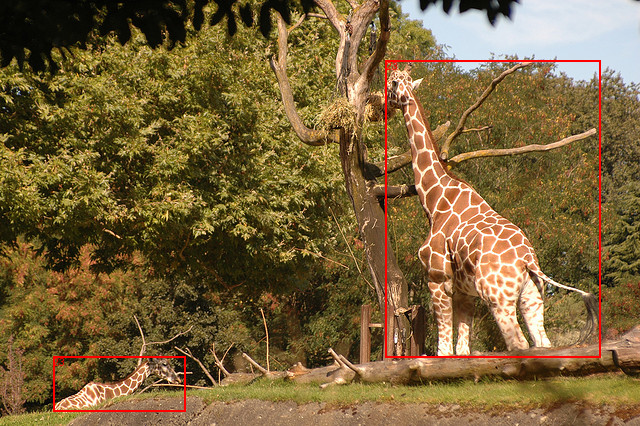

In [ ]:
data = next(iteration)
data['image']

# --- Dessin des bounding boxes ---

image_with_bboxes = data['image'].copy()
draw = ImageDraw.Draw(image_with_bboxes)

ground_truth_bboxes = data['objects']['bbox']
categories = data['objects']['category']

for i, box in enumerate(ground_truth_bboxes):
    x_min = box[0]
    y_min = box[1]
    x_max = box[0] + box[2]
    y_max = box[1] + box[3]
    draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)
    draw.text((x_min, y_min), str(categories[i]), fill="red")

image_with_bboxes

# Calcul de la mAP

In [ ]:
# PARAMÈTRES DE SIMULATION

NOMBRES_IMAGES_SIMULEES = 100
SEUIL_IOU = 0.5

In [ ]:
# --- SIMULATION DES PRÉDICTIONS ---

prediction_results = []  # Liste pour stocker les résultats des prédictions simulées
total_real_objects = 0 # Compteur pour le nombre total d'objets à detecter dans les images simulées

for gt_box in ground_truth_bboxes:
    total_real_objects += 1

    # Simulation du modèle de détection d'objets (on crée des prédictions aléatoires)
    prediction_box, score = generate_fake_prediction(gt_box, data['width'], data['height'])

    # Evaluation de la detection simulée
    iou = calculate_iou(gt_box, prediction_box)

    if iou >= SEUIL_IOU:
        prediction_results.append((score, 1))
    else:
        prediction_results.append((score, 0))

    # Tri des résultats par score de confiance décroissant
    prediction_results.sort(key=lambda x: x[0], reverse=True)

    # Calcul des TP et FP cumulés (true positives et false positives)
    tp_cumules = []
    fp_cumules = []
    tp_sum = 0
    fp_sum = 0

    for score, is_tp in prediction_results:
        if is_tp == 1:
            tp_sum += 1
        else:
            fp_sum += 1
        tp_cumules.append(tp_sum)
        fp_cumules.append(fp_sum)
 
    # Calcul du rappel et de la précision
    tp_cumules = np.array(tp_cumules)
    fp_cumules = np.array(fp_cumules)

    precisions = tp_cumules / (tp_cumules + fp_cumules) # TP / (TP + FP)
    recalls = tp_cumules / total_real_objects # TP / FN + TP

    map = 





NameError: name 'image_w' is not defined